# Trabajo Práctico 1 - Visión por Computadora I

Resolución basada en los ejemplos de `Codigo/Clase1` y `Codigo/Clase2`.

In [1]:
from pathlib import Path

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

BASE = Path('Material_TPs/TP1')
if not BASE.exists():
    BASE = Path('.')

In [2]:
def leer_imagen(ruta, modo=cv.IMREAD_COLOR):
    """Lee una imagen con OpenCV y falla explícitamente si no se pudo cargar."""
    img = cv.imread(str(ruta), modo)
    if img is None:
        raise FileNotFoundError(f'No se pudo leer la imagen: {ruta}')
    return img


def mostrar_grilla(imagenes, titulos, columnas):
    """Muestra imágenes BGR o en escala de grises en una grilla, con un título por imagen."""
    filas = int(np.ceil(len(imagenes) / columnas))
    _, axes = plt.subplots(filas, columnas, figsize=(4 * columnas, 3.5 * filas), squeeze=False)
    for ax in axes.flat:
        ax.axis('off')
    for ax, img, titulo in zip(axes.flat, imagenes, titulos):
        if img.ndim == 2:
            ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        else:
            ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        ax.set_title(titulo)
    plt.tight_layout()
    plt.show()

## Parte 1 - White Patch

Una luz de color tiñe toda la escena. White Patch lo corrige suponiendo que el punto más brillante de cada canal es una superficie blanca, y escala cada canal para que ese máximo llegue a 255:

$$(R, G, B) \rightarrow \left(\frac{255}{R_{max}}\,R,\ \frac{255}{G_{max}}\,G,\ \frac{255}{B_{max}}\,B\right)$$

La estimación del blanco se separa de la corrección para poder cambiarla en la mejora.

In [3]:
def blanco_maximo(img):
    """Hipótesis de White Patch: el blanco de la escena es el máximo de cada canal."""
    return img.max(axis=(0, 1)).astype(np.float32)


def corregir_con_blanco(img, blanco):
    """Aplica una ganancia por canal para que el color `blanco` (B, G, R) pase a valer 255."""
    ganancias = 255 / np.maximum(blanco, 1)
    corregida = img.astype(np.float32) * ganancias
    return np.clip(np.round(corregida), 0, 255).astype(np.uint8)


def white_patch(img):
    return corregir_con_blanco(img, blanco_maximo(img))


def formatear(valores, decimales):
    return ', '.join(f'{valor:.{decimales}f}' for valor in valores)


def imprimir_resumen(casos):
    """Tabla por caso (etiqueta, imagen, blanco): blanco, ganancias y % de píxeles que terminan en 255."""
    print(f'{"caso":<16}{"blanco (B, G, R)":<20}{"ganancias (B, G, R)":<22}% en 255 (B, G, R)')
    for etiqueta, img, blanco in casos:
        ganancias = 255 / np.maximum(blanco, 1)
        saturados = 100 * np.mean(corregir_con_blanco(img, blanco) == 255, axis=(0, 1))
        print(f'{etiqueta:<16}{formatear(blanco, 0):<20}{formatear(ganancias, 2):<22}{formatear(saturados, 2)}')

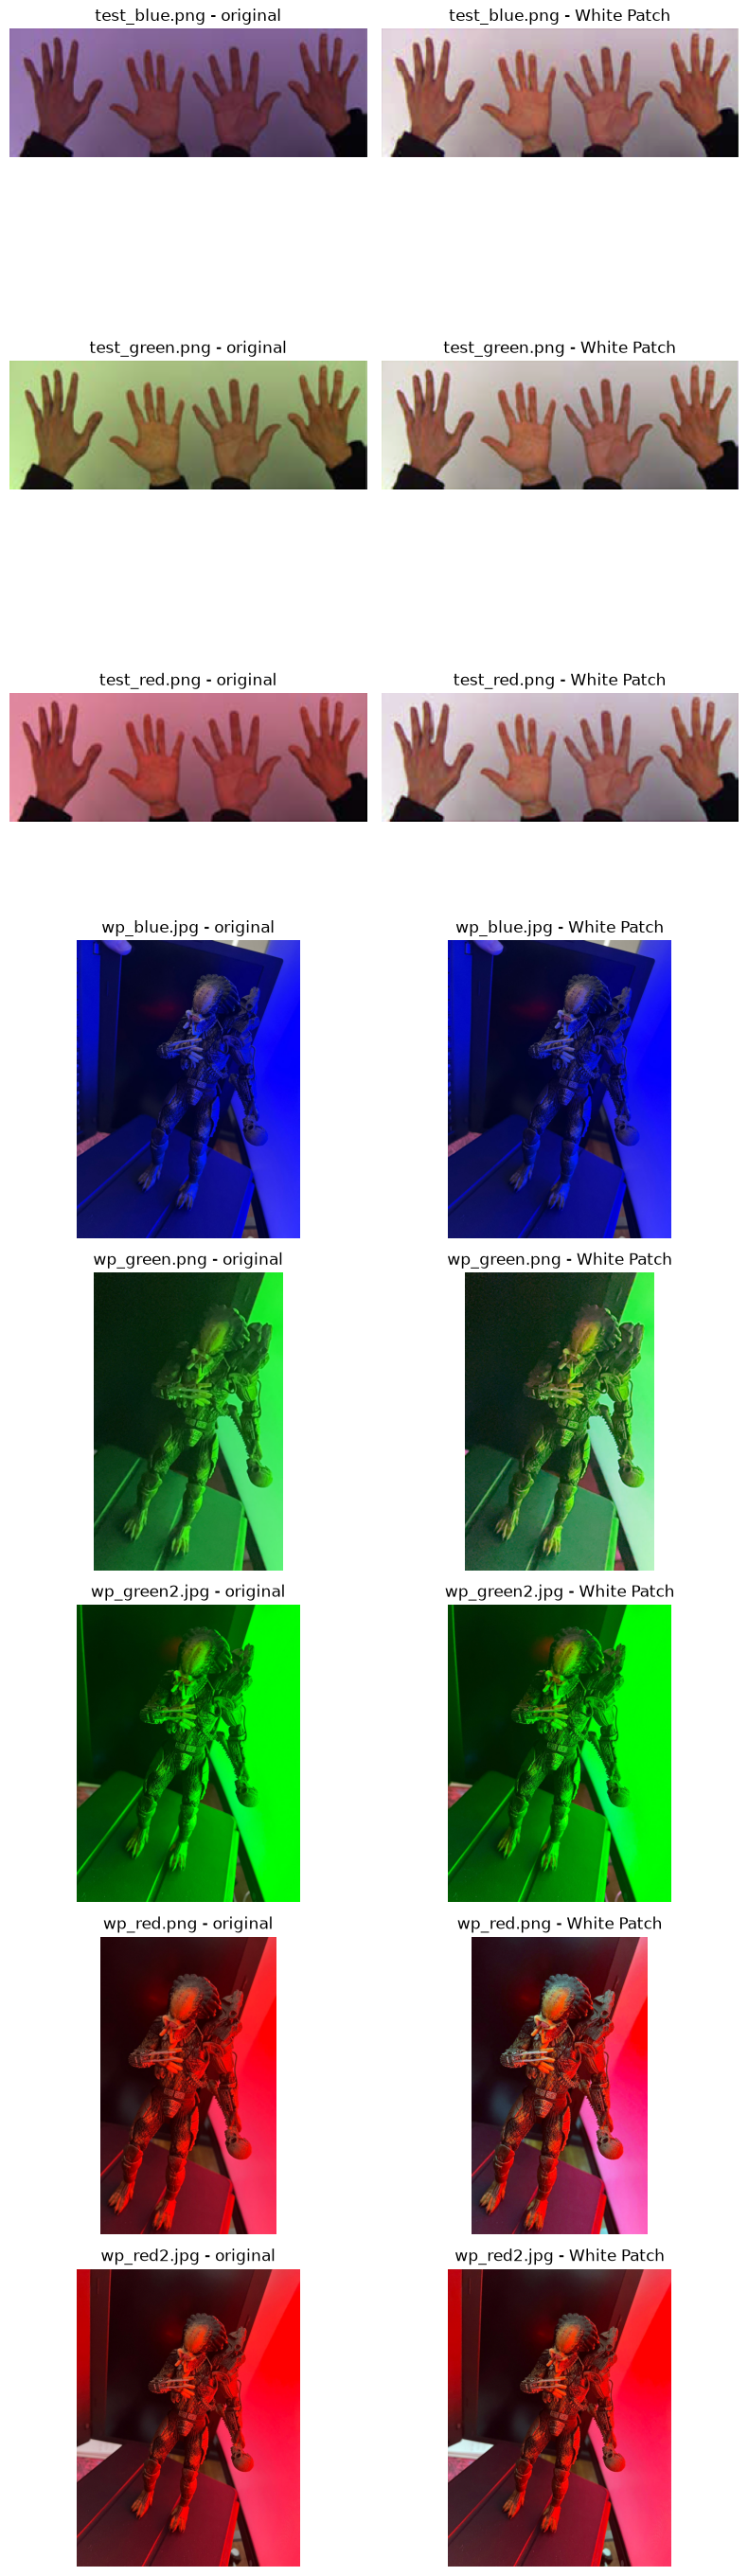

caso            blanco (B, G, R)    ganancias (B, G, R)   % en 255 (B, G, R)
test_blue.png   200, 138, 165       1.27, 1.85, 1.55      0.01, 0.00, 0.00
test_green.png  171, 250, 210       1.49, 1.02, 1.21      0.00, 0.01, 0.00
test_red.png    175, 157, 247       1.46, 1.62, 1.03      0.00, 0.01, 0.00
wp_blue.jpg     255, 255, 255       1.00, 1.00, 1.00      0.51, 0.00, 0.00
wp_green.png    155, 252, 126       1.65, 1.01, 2.02      0.00, 0.00, 0.00
wp_green2.jpg   172, 255, 170       1.48, 1.00, 1.50      0.00, 5.14, 0.00
wp_red.png      122, 134, 255       2.09, 1.90, 1.00      0.00, 0.00, 6.46
wp_red2.jpg     203, 201, 255       1.26, 1.27, 1.00      0.00, 0.00, 9.10


In [4]:
EXTENSIONES = {'.png', '.jpg'}
archivos = sorted(ruta for ruta in (BASE / 'white_patch').iterdir() if ruta.suffix.lower() in EXTENSIONES)
imagenes = {archivo.name: leer_imagen(archivo) for archivo in archivos}

resultados, titulos = [], []
for nombre, img in imagenes.items():
    resultados += [img, white_patch(img)]
    titulos += [f'{nombre} - original', f'{nombre} - White Patch']
mostrar_grilla(resultados, titulos, columnas=2)

imprimir_resumen([(nombre, img, blanco_maximo(img)) for nombre, img in imagenes.items()])

### Análisis

- **`test_*`**: funciona bien. El máximo de cada canal cae en el fondo claro, que cumple la hipótesis.
- **`wp_blue.jpg`**: no corrige nada. Un pequeño reflejo (54 px en G y 22 en R, de 1,92 millones) ya vale 255 en los tres canales, así que las ganancias son 1.
- **`wp_green*` y `wp_red*`**: mejora leve. El canal dominante está saturado y los máximos de los otros canales los fijan unos pocos píxeles brillantes.

**Limitaciones:**

1. Un solo píxel por canal define el blanco, y puede ser un reflejo, ruido o un objeto distinto en cada canal.
2. Si la escena no tiene nada blanco, se "corrige" el color del objeto más brillante.
3. Lo saturado en 255 no se recupera, y amplificar canales débiles amplifica el ruido.
4. Supone un único iluminante para toda la imagen.

La primera limitación se puede resolver con un cambio mínimo.

### Mejora: percentil 99 en lugar del máximo

Se toma como blanco el percentil 99 de cada canal. Así el blanco debe estar respaldado por al menos el 1 % de la imagen, y un reflejo aislado ya no alcanza para fijarlo.

**Por qué 99:** todo lo que supera la referencia se satura, así que un percentil $p$ satura ~$(100 - p)$ % de los píxeles.

- **99,9 no alcanza**: en `wp_blue.jpg` la referencia de G sigue en 166 por el reflejo (con 99 baja a 86).
- **97 o 95 cuestan demasiado**: saturan el 3-5 % de la imagen.
- **99 es el punto medio**: descarta el reflejo perdiendo sólo ~1 %.

In [5]:
PERCENTIL_BLANCO = 99


def blanco_percentil(img, percentil):
    """Blanco robusto: descarta el (100 - percentil) % de píxeles más brillantes de cada canal."""
    return np.percentile(img, percentil, axis=(0, 1))


def white_patch_robusto(img, percentil=PERCENTIL_BLANCO):
    return corregir_con_blanco(img, blanco_percentil(img, percentil))


# Barrido sobre el caso problemático: cómo cambian la referencia y la saturación según el percentil.
img_azul = imagenes['wp_blue.jpg']
imprimir_resumen([(f'p{p}', img_azul, blanco_percentil(img_azul, p)) for p in (100, 99.9, 99, 97, 95)])

caso            blanco (B, G, R)    ganancias (B, G, R)   % en 255 (B, G, R)
p100            255, 255, 255       1.00, 1.00, 1.00      0.51, 0.00, 0.00


p99.9           255, 166, 167       1.00, 1.54, 1.53      0.51, 0.11, 0.11
p99             254, 86, 117        1.00, 2.97, 2.18      1.17, 1.04, 1.01
p97             253, 61, 69         1.01, 4.18, 3.70      3.38, 3.05, 3.07


p95             252, 51, 56         1.01, 5.00, 4.55      5.69, 5.27, 5.04


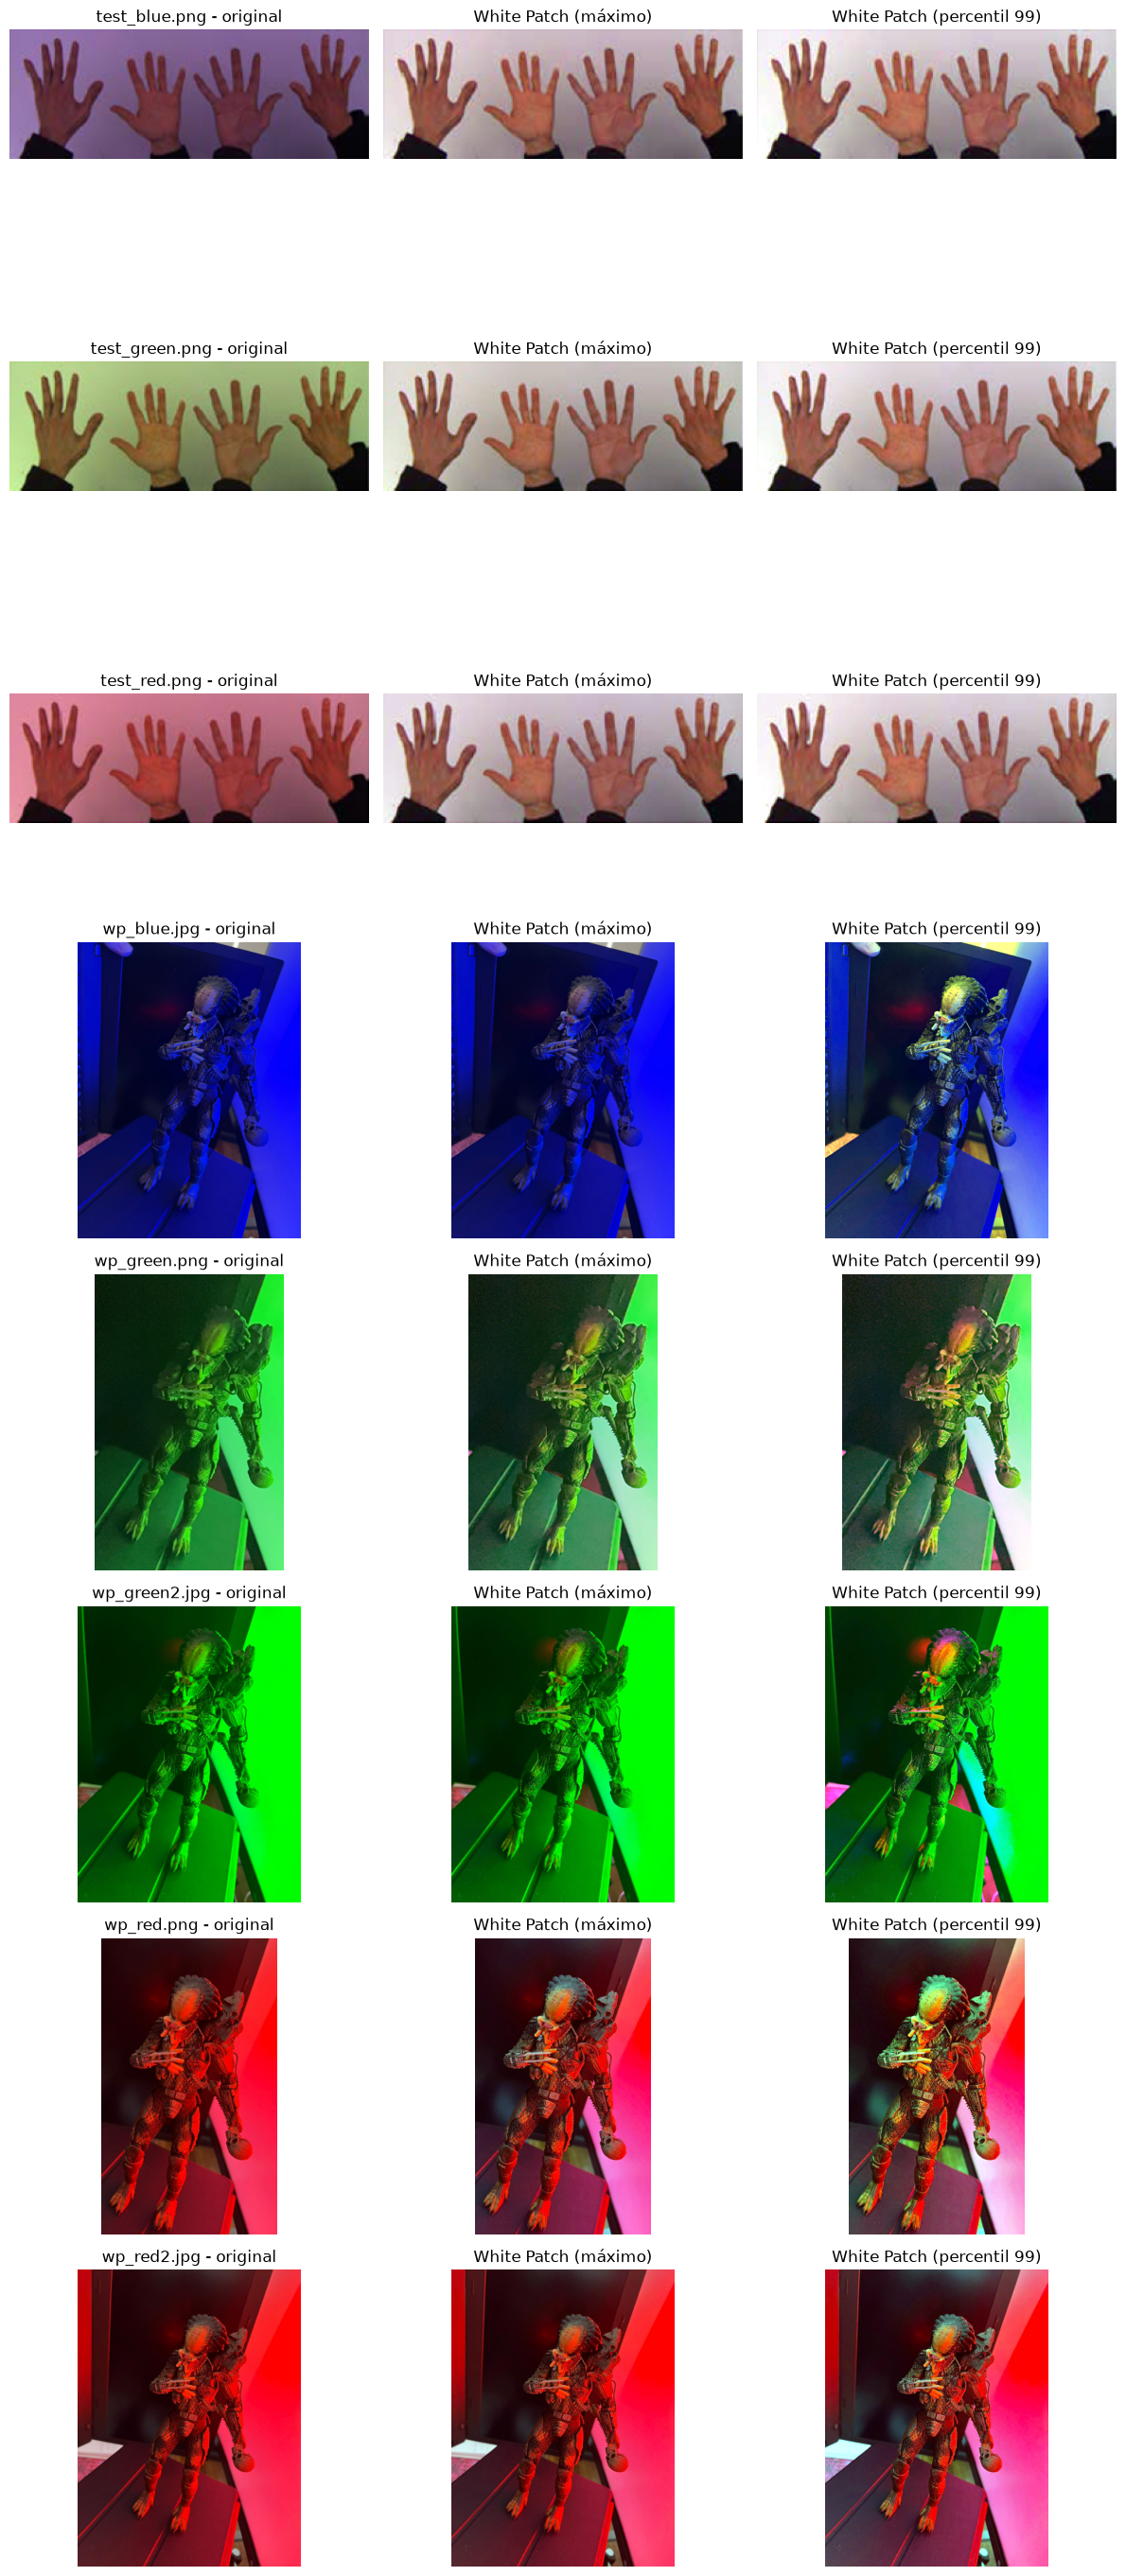

caso            blanco (B, G, R)    ganancias (B, G, R)   % en 255 (B, G, R)
test_blue.png   180, 122, 153       1.42, 2.09, 1.67      1.13, 1.20, 1.35
test_green.png  150, 230, 193       1.70, 1.11, 1.32      1.10, 1.10, 1.05
test_red.png    163, 143, 230       1.56, 1.78, 1.11      1.27, 1.16, 1.26
wp_blue.jpg     254, 86, 117        1.00, 2.97, 2.18      1.17, 1.04, 1.01
wp_green.png    120, 244, 88        2.12, 1.05, 2.90      1.11, 1.13, 1.43
wp_green2.jpg   56, 255, 70         4.55, 1.00, 3.64      1.05, 5.14, 1.05
wp_red.png      102, 74, 255        2.50, 3.45, 1.00      1.09, 1.06, 6.46
wp_red2.jpg     119, 119, 255       2.14, 2.14, 1.00      1.00, 1.00, 9.10


In [6]:
resultados, titulos = [], []
for nombre, img in imagenes.items():
    resultados += [img, white_patch(img), white_patch_robusto(img)]
    titulos += [f'{nombre} - original', 'White Patch (máximo)', f'White Patch (percentil {PERCENTIL_BLANCO})']
mostrar_grilla(resultados, titulos, columnas=3)

imprimir_resumen([(nombre, img, blanco_percentil(img, PERCENTIL_BLANCO)) for nombre, img in imagenes.items()])

### Resultados

- **`wp_blue.jpg`**: las ganancias pasan de (1; 1; 1) a (1; 2,97; 2,18) y desaparece la dominante azul sobre la figura.
- **`wp_green.png` y `wp_red.png`**: la pared queda casi blanca y la figura, más neutra.
- **`wp_green2.jpg` y `wp_red2.jpg`**: mejora parcial. El canal dominante está saturado en el 5-9 % de la imagen y eso no se recupera; además, las ganancias altas amplifican el ruido.
- **`test_*`**: prácticamente sin cambios.

**Conclusión:** el percentil 99 elimina la sensibilidad a *outliers* con un costo de ~1 % de píxeles saturados. Las demás limitaciones siguen presentes.

## Parte 2 - Histogramas

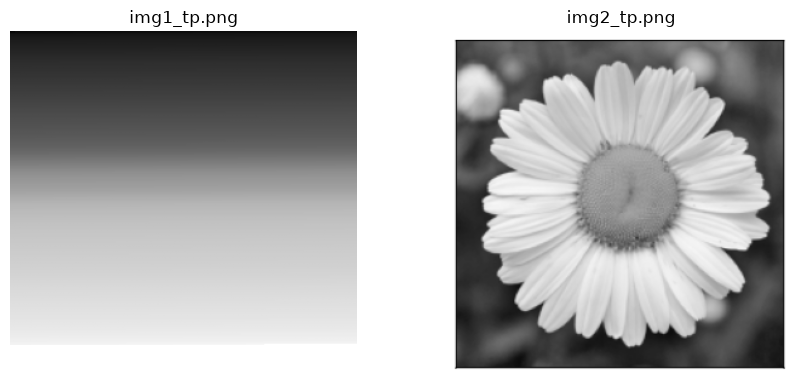

In [4]:
img1 = cv.imread(str(BASE / 'img1_tp.png'), cv.IMREAD_GRAYSCALE)
img2 = cv.imread(str(BASE / 'img2_tp.png'), cv.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('img1_tp.png')
axes[1].imshow(img2, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('img2_tp.png')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

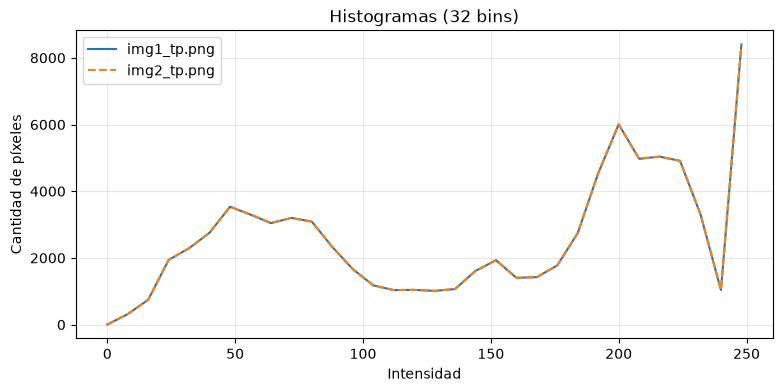

¿Los histogramas son iguales? True


In [5]:
bins = 32
hist1, bordes = np.histogram(img1.ravel(), bins=bins, range=(0, 256))
hist2, _ = np.histogram(img2.ravel(), bins=bins, range=(0, 256))

plt.figure(figsize=(9, 4))
plt.plot(bordes[:-1], hist1, label='img1_tp.png')
plt.plot(bordes[:-1], hist2, '--', label='img2_tp.png')
plt.xlabel('Intensidad')
plt.ylabel('Cantidad de píxeles')
plt.title(f'Histogramas ({bins} bins)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print('¿Los histogramas son iguales?', np.array_equal(hist1, hist2))

### Análisis

Se eligieron 32 bins: agrupan niveles vecinos y permiten ver claramente la forma global sin el ruido visual de 256 barras. Las dos imágenes son completamente distintas, pero sus histogramas coinciden: tienen la misma cantidad de píxeles para cada rango de intensidad y sólo cambia su posición espacial.

Por lo tanto, un histograma puede servir como *feature* global para describir brillo, contraste o distribución de color, y puede ser útil si esas propiedades distinguen las clases. Sin embargo, por sí solo no es suficiente para clasificación o detección: descarta forma, textura y ubicación. Este par es un contraejemplo directo, porque un modelo basado únicamente en estos histogramas no podría separar ambas imágenes. Para detección, además, se necesita información espacial; podrían usarse histogramas por regiones como complemento, pero no reemplazan descriptores que preserven la estructura.